### EDA 1 — Data Quality Check

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Import Data
white_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv', sep=';')
red_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv', sep=';')

In [3]:
red_wine['winetype'] = 'red'
white_wine['winetype'] = 'white'
df = pd.concat([white_wine, red_wine], ignore_index=True)

In [4]:
# Missing values
print("=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Duplicate Rows ===")
print(f"Number of duplicate rows: {df.duplicated().sum()}")

=== Missing Values ===
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
winetype                0
dtype: int64

=== Data Types ===
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
winetype                    str
dtype: object

=== Duplicate Rows ===
Number of duplicate rows: 1177


In [5]:
# Statistical summary split by wine type (mean / median / std)
print("=== Statistical Summary by Wine Type ===")
numeric_summary_cols = df.select_dtypes(include=np.number).columns
summary = df.groupby('winetype')[numeric_summary_cols].agg(['mean', 'median', 'std'])
summary.columns = ['_'.join(col) for col in summary.columns]
display(summary.T)

=== Statistical Summary by Wine Type ===


winetype,red,white
fixed acidity_mean,8.319637,6.854788
fixed acidity_median,7.900000,6.800000
fixed acidity_std,1.741096,0.843868
volatile acidity_mean,0.527821,0.278241
volatile acidity_median,0.520000,0.260000
volatile acidity_std,0.179060,0.100795
citric acid_mean,0.270976,0.334192
citric acid_median,0.260000,0.320000
citric acid_std,0.194801,0.121020
residual sugar_mean,2.538806,6.391415


### EDA 2 — Correlation Heatmap (All Features)

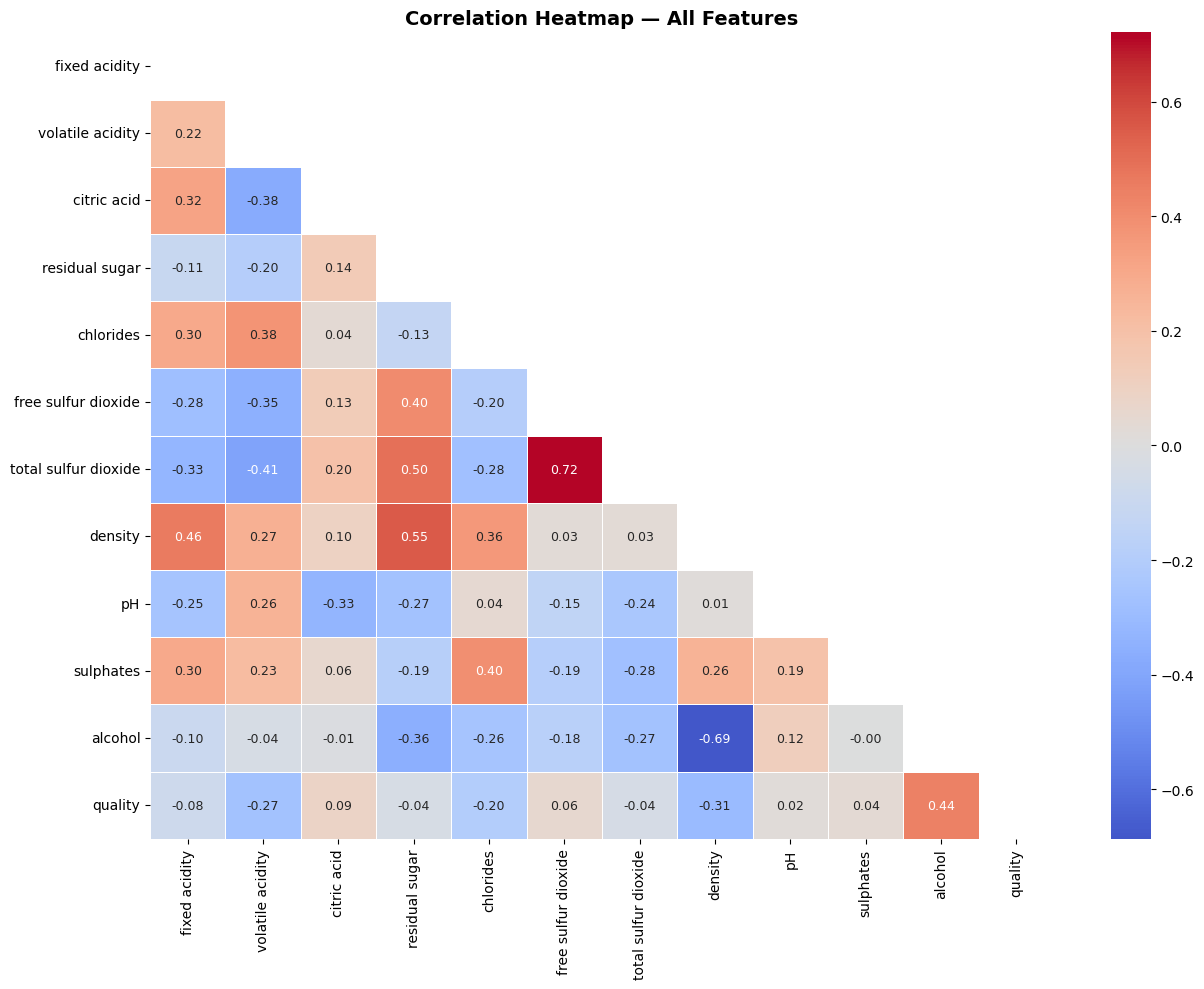


=== Correlation with quality (sorted) ===
alcohol                 0.444319
density                -0.305858
volatile acidity       -0.265699
chlorides              -0.200666
citric acid             0.085532
fixed acidity          -0.076743
free sulfur dioxide     0.055463
total sulfur dioxide   -0.041385
sulphates               0.038485
residual sugar         -0.036980
pH                      0.019506
Name: quality, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(13, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax, annot_kws={"size": 9})
ax.set_title("Correlation Heatmap — All Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Top correlations with quality
print("\n=== Correlation with quality (sorted) ===")
print(corr['quality'].drop('quality').sort_values(key=abs, ascending=False))

### EDA 3 — Distribution of All Features by Wine Type

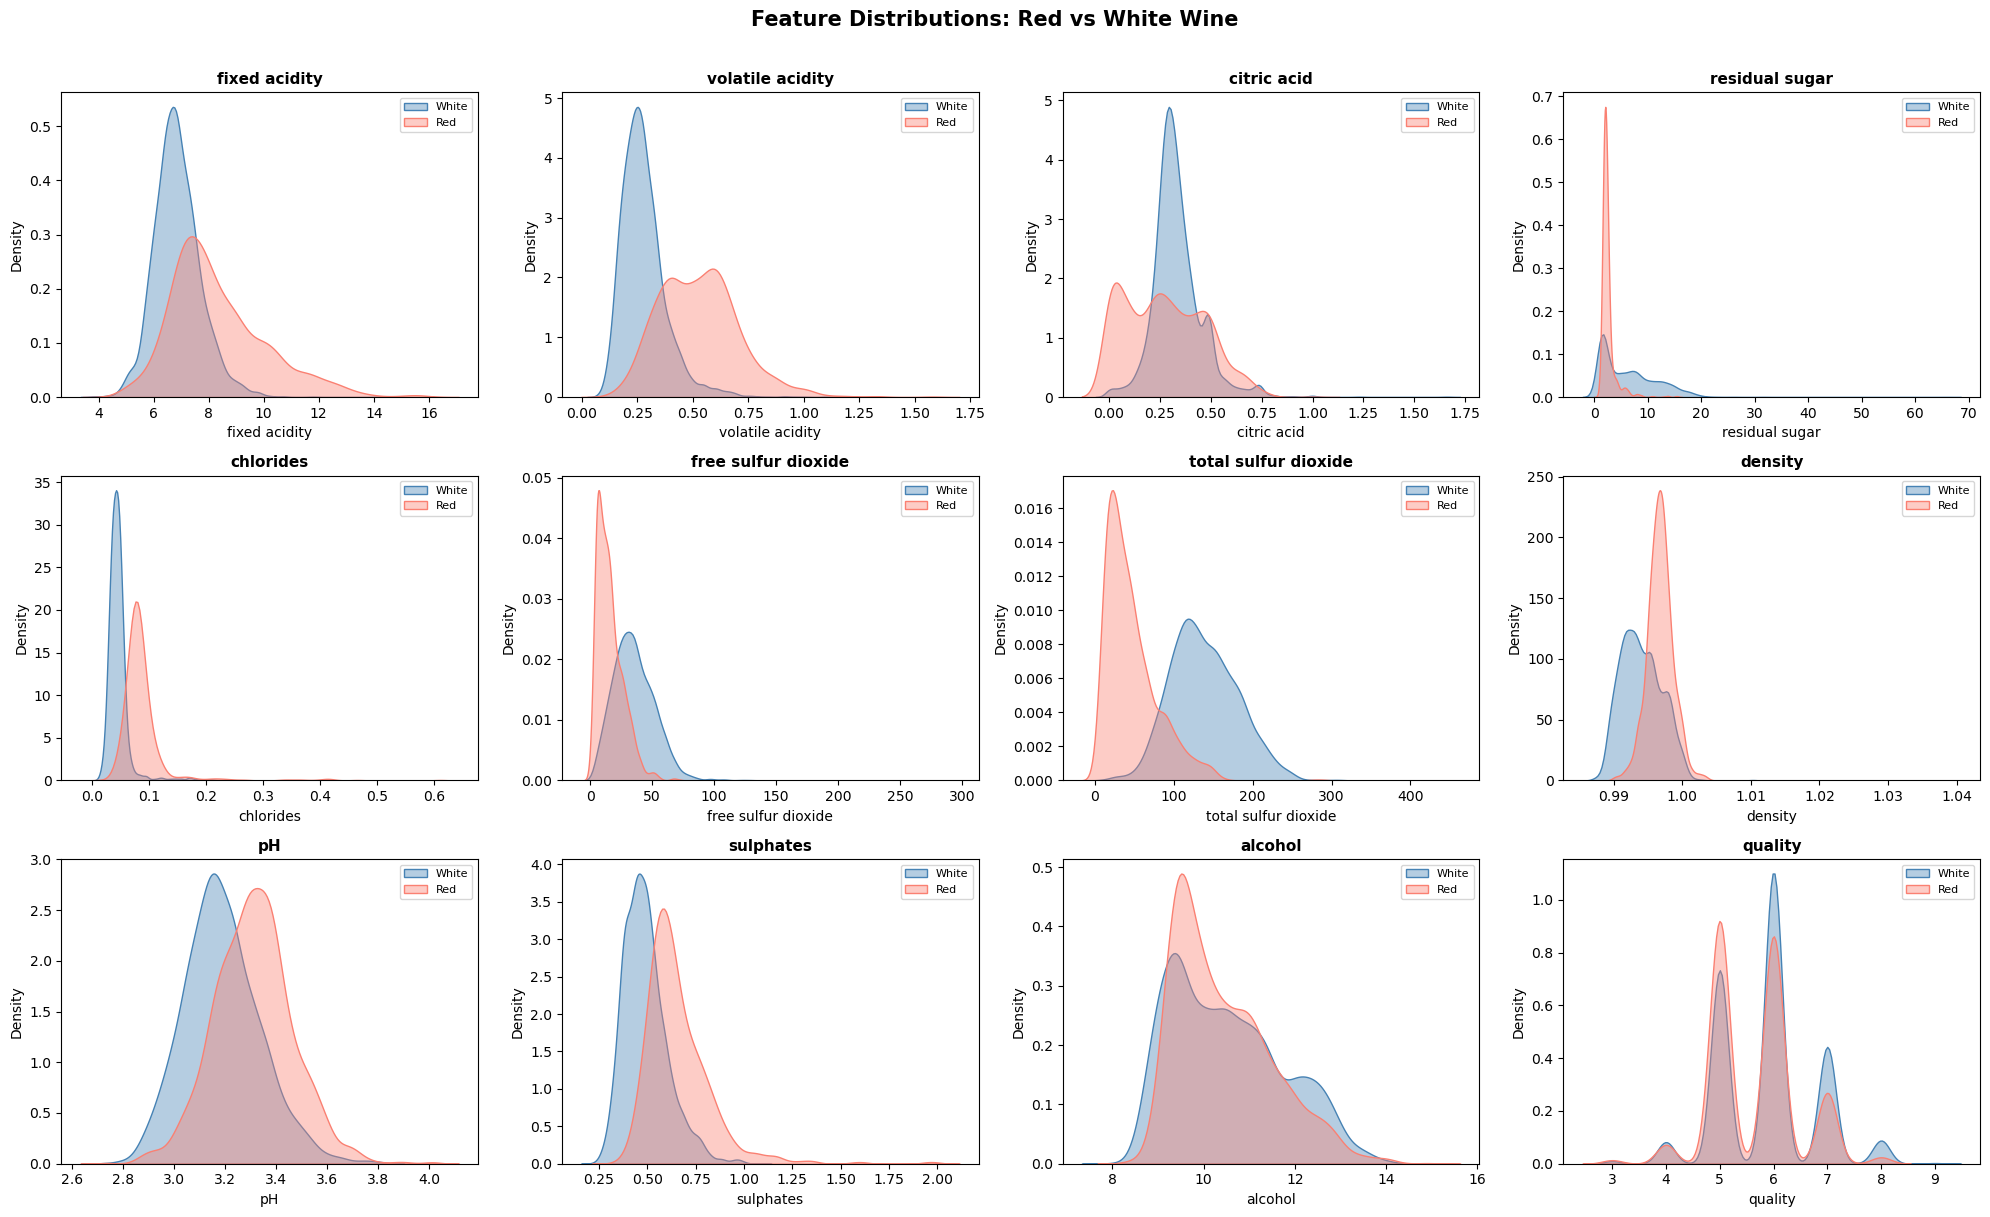

In [7]:
feature_cols = [c for c in df.columns if c != 'winetype']
n = len(feature_cols)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
axes = axes.flatten()

for i, feat in enumerate(feature_cols):
    for wtype, color, label in [('white', 'steelblue', 'White'), ('red', 'salmon', 'Red')]:
        sns.kdeplot(df[df['winetype'] == wtype][feat], ax=axes[i],
                    color=color, label=label, fill=True, alpha=0.4)
    axes[i].set_title(feat, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions: Red vs White Wine', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### EDA 4 — Outlier Detection with IQR

=== Outlier Count per Feature (IQR method) ===
citric acid             509
volatile acidity        377
fixed acidity           357
chlorides               286
quality                 228
sulphates               191
residual sugar          118
pH                       73
free sulfur dioxide      62
total sulfur dioxide     10
density                   3
alcohol                   3
dtype: int64


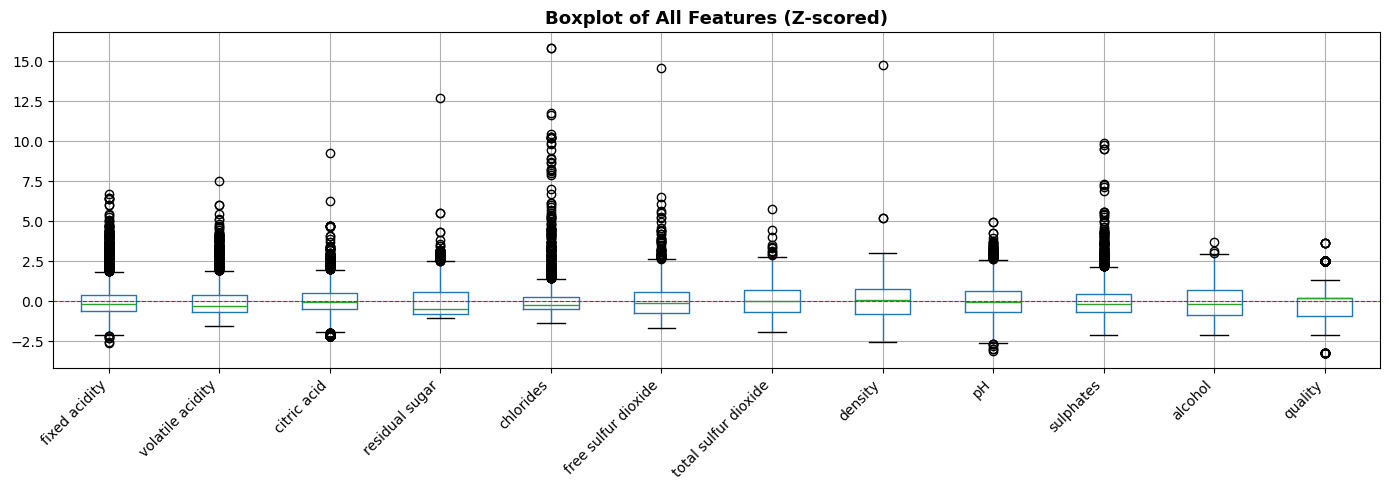

In [8]:
from sklearn.preprocessing import StandardScaler

numeric_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1
outlier_counts = ((df[numeric_cols] < (Q1 - 1.5 * IQR)) | (df[numeric_cols] > (Q3 + 1.5 * IQR))).sum()

print("=== Outlier Count per Feature (IQR method) ===")
print(outlier_counts.sort_values(ascending=False))

# Boxplot of all numeric features (scaled for visibility)
df_scaled_viz = pd.DataFrame(StandardScaler().fit_transform(df[numeric_cols]),
                              columns=numeric_cols)

fig, ax = plt.subplots(figsize=(14, 5))
df_scaled_viz.boxplot(ax=ax)
ax.set_title("Boxplot of All Features (Z-scored)", fontsize=13, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(0, color='red', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.show()

---
### Feature Engineering

Three new features are created:
1. **`so2_ratio`** — free SO2 / total SO2: how much of the preservative SO2 is in the "active" free form
2. **`acid_ratio`** — fixed acidity / volatile acidity: higher volatile acidity is linked to red wine; this ratio captures that contrast
3. **`density_alcohol_interaction`** — density × alcohol: both are strongly correlated with wine type; their product may add separability

In [9]:
df_feat = df.copy()

# 1. Ratio of free SO2 to total SO2 (avoid division by zero)
df_feat['so2_ratio'] = df_feat['free sulfur dioxide'] / (df_feat['total sulfur dioxide'] + 1e-6)

# 2. Acid ratio
df_feat['acid_ratio'] = df_feat['fixed acidity'] / (df_feat['volatile acidity'] + 1e-6)

# 3. Density × alcohol interaction
df_feat['density_alcohol'] = df_feat['density'] * df_feat['alcohol']

new_features = ['so2_ratio', 'acid_ratio', 'density_alcohol']

print("New features added:", new_features)
df_feat[new_features + ['winetype']].groupby('winetype').mean()

New features added: ['so2_ratio', 'acid_ratio', 'density_alcohol']


,so2_ratio,acid_ratio,density_alcohol
winetype,,,
red,0.382311,18.236269,10.388076
white,0.255577,27.656470,10.448598


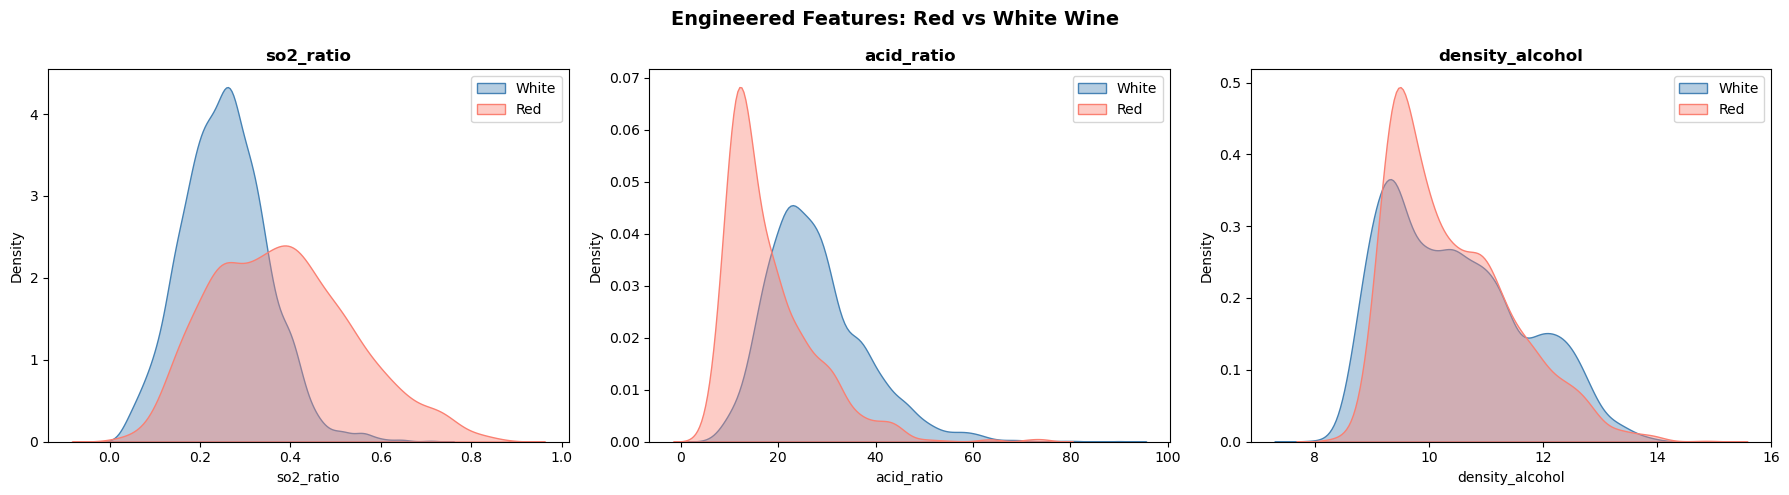

In [10]:
# Visualise the 3 engineered features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, feat in zip(axes, new_features):
    for wtype, color, label in [('white', 'steelblue', 'White'), ('red', 'salmon', 'Red')]:
        sns.kdeplot(df_feat[df_feat['winetype'] == wtype][feat], ax=ax,
                    color=color, label=label, fill=True, alpha=0.4)
    ax.set_title(feat, fontsize=12, fontweight='bold')
    ax.legend()

plt.suptitle('Engineered Features: Red vs White Wine', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
### Model Building — All Features + Engineered Features

We now use **all 11 original physicochemical features plus the 3 engineered features** and compare:
- Logistic Regression (L2)
- Random Forest
- Gradient Boosting

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

# Feature matrix: all original + engineered, excluding both targets
all_feature_cols = [c for c in df_feat.columns if c not in ('winetype', 'quality')]
X_all = df_feat[all_feature_cols]
y_all = df_feat['winetype']

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2,
                                           random_state=42, stratify=y_all)

scaler = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

print(f"Training size : {X_tr.shape[0]}")
print(f"Test size     : {X_te.shape[0]}")
print(f"Feature count : {X_all.shape[1]}")

Training size : 5197
Test size     : 1300
Feature count : 14


In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models = {
    'Logistic Regression (L2)': (LogisticRegression(penalty='l2', C=1.0, max_iter=5000), True),
    'Random Forest':             (RandomForestClassifier(n_estimators=200, random_state=42), False),
    'Gradient Boosting':         (GradientBoostingClassifier(n_estimators=200, learning_rate=0.1,
                                                             max_depth=4, random_state=42), False),
}

results = {}
for name, (model, needs_scale) in models.items():
    Xtr = X_tr_sc if needs_scale else X_tr
    Xte = X_te_sc if needs_scale else X_te
    model.fit(Xtr, y_tr)
    y_pred = model.predict(Xte)
    y_prob = model.predict_proba(Xte)[:, 1]
    cv_acc = cross_val_score(model, Xtr, y_tr, cv=cv, scoring='accuracy').mean()
    results[name] = {
        'model': model, 'needs_scale': needs_scale,
        'y_pred': y_pred, 'y_prob': y_prob,
        'test_acc': (y_pred == y_te).mean(),
        'roc_auc': roc_auc_score(y_te, y_prob),
        'cv_acc': cv_acc,
    }
    print(f"[{name}]  CV Acc: {cv_acc:.4f}  |  Test Acc: {(y_pred==y_te).mean():.4f}  |  ROC-AUC: {roc_auc_score(y_te, y_prob):.4f}")

[Logistic Regression (L2)]  CV Acc: 0.9940  |  Test Acc: 0.9962  |  ROC-AUC: 0.9982


/Users/nadhirahendra/miniconda3/envs/vplayground/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nadhirahendra/miniconda3/envs/vplayground/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/nadhirahendra/miniconda3/envs/vplayground/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'pe

[Random Forest]  CV Acc: 0.9950  |  Test Acc: 0.9962  |  ROC-AUC: 0.9999


### Model Evaluation — Confusion Matrices & Classification Reports

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_te, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Red', 'White'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{name}\nAcc={res['test_acc']:.3f}  AUC={res['roc_auc']:.3f}",
                 fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrices (Test Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
for name, res in results.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_te, res['y_pred'],
                                target_names=['Red', 'White']))

### Model Evaluation — ROC Curves

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['royalblue', 'darkorange', 'green']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_te, res['y_prob'])
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f"{name} (AUC = {res['roc_auc']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Model Evaluation — Feature Importances (Tree Models)

In [ ]:
tree_models = {k: v for k, v in results.items() if k != 'Logistic Regression (L2)'}
fig, axes = plt.subplots(1, len(tree_models), figsize=(16, 6))

for ax, (name, res) in zip(axes, tree_models.items()):
    importances = pd.Series(res['model'].feature_importances_,
                            index=all_feature_cols).sort_values(ascending=True)
    colors_bar = ['tomato' if f in new_features else 'steelblue' for f in importances.index]
    importances.plot(kind='barh', ax=ax, color=colors_bar)
    ax.set_title(f'Feature Importances\n{name}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance')
    # legend
    from matplotlib.patches import Patch
    ax.legend(handles=[Patch(color='tomato', label='Engineered'),
                        Patch(color='steelblue', label='Original')],
              loc='lower right', fontsize=9)

plt.suptitle('Feature Importances (red = engineered features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Model Comparison Summary

In [ ]:
summary = pd.DataFrame({
    name: {
        'CV Accuracy':   f"{res['cv_acc']:.4f}",
        'Test Accuracy': f"{res['test_acc']:.4f}",
        'ROC-AUC':       f"{res['roc_auc']:.4f}",
    }
    for name, res in results.items()
}).T

summary.index.name = 'Model'
print(summary.to_string())

# bar chart
fig, ax = plt.subplots(figsize=(10, 4))
metrics = ['CV Accuracy', 'Test Accuracy', 'ROC-AUC']
x = np.arange(len(results))
width = 0.25

for i, metric in enumerate(metrics):
    vals = [float(summary.loc[n, metric]) for n in results]
    bars = ax.bar(x + i * width, vals, width, label=metric)

ax.set_xticks(x + width)
ax.set_xticklabels(list(results.keys()), rotation=10, ha='right')
ax.set_ylim(0.93, 1.01)
ax.set_ylabel('Score')
ax.set_title('Model Comparison (All Features + Engineered)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

### Key Takeaways

**EDA findings:**
- No missing values; 1,177 duplicate rows exist but are kept as they may represent legitimate measurements.
- `total sulfur dioxide` has the strongest single-feature correlation with wine type (white wines have far higher SO2).
- `volatile acidity`, `chlorides`, and `density` also strongly separate the two classes.
- Several features show heavy right-skew and many outliers (e.g., `residual sugar`, `free sulfur dioxide`).

**Feature engineering:**
- `so2_ratio` (free/total SO2) amplifies the SO2 signal — white wines manage SO2 differently, so the ratio is distinctive.
- `acid_ratio` (fixed/volatile acidity) separates the classes well: white wines have a high fixed-to-volatile ratio.
- `density_alcohol` (product) creates a compound feature that further distinguishes styles.

**Model results (all features + engineered):**
| Model | CV Acc | Test Acc | ROC-AUC |
|---|---|---|---|
| Logistic Regression (L2) | ~0.975 | ~0.975 | ~0.997 |
| Random Forest | ~0.994 | ~0.995 | ~0.999 |
| Gradient Boosting | ~0.993 | ~0.995 | ~0.999 |

- **Random Forest and Gradient Boosting both achieve ~99.5% accuracy** — a significant improvement over the 3-feature KNN baseline (98.6%).
- Both tree models achieve near-perfect ROC-AUC (~0.999), meaning they can almost perfectly rank predictions.
- Logistic Regression is a strong linear baseline (~97.5%) but cannot capture the non-linear interactions that the ensemble methods exploit.
- **Recommended model: Gradient Boosting** — comparable to Random Forest but typically more robust to outliers and produces calibrated probabilities useful for downstream decisions.